# Paired color-code code-capacity numerics

Use the `color_code_so` Conda kernel. Corrected one-round bit-flip code; selected-color swim is empirical and uncertified. The fallback grid is a project approximation. Full default run: 4.8 million paired shots. Read the smoke throughput before starting it.

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2   
from pathlib import Path
from color_code_softoutput.simulation.config import Phase2ATestConfig
from color_code_softoutput.experiments.phase_2a_test import run_experiment
from color_code_softoutput.analysis.dataset import Phase2ADataset
from color_code_softoutput.analysis.audit import audit_run
from color_code_softoutput.analysis.prior_work import LeeFig3ReproductionAnalyzer
from color_code_softoutput.analysis.swim_distribution import SwimDistanceDistributionPlotter
from color_code_softoutput.analysis.conditional_ler import ConditionalLERAnalyzer
from color_code_softoutput.analysis.postselection import PostSelectionAnalyzer
from color_code_softoutput.analysis.selection import select_series

In [3]:
shots_per_point = 100_000
num_workers = 6
batch_size = 2_000
master_seed = 20260912321
verbose = True
config = Phase2ATestConfig(shots_per_point=shots_per_point, num_workers=num_workers,
    batch_size=batch_size, master_seed=master_seed, verbose=verbose)
config.resolved()

{'distances': (5, 7, 9, 11, 13, 15),
 'near_threshold_ps': (0.082, 0.084, 0.085, 0.086, 0.087, 0.088),
 'subthreshold_ps': (0.02, 0.03, 0.04, 0.05),
 'shots_per_point': 100000,
 'batch_size': 2000,
 'num_workers': 6,
 'master_seed': 20260912321,
 'output_root': '/home/quantum_teresheys/workspace/color_code_softoutput/results',
 'verbose': True}

Either run the configured experiment or open an existing run. Sampling is disabled by default so reopening this notebook does not start millions of shots.

In [4]:
RUN_NEW_EXPERIMENT = False  # Set to False to analyze an existing run instead of running a new experiment.
existing_run = "/home/quantum_teresheys/workspace/color_code_softoutput/results/20260912_152533_phase2a_test"  # Set to a timestamped results directory, or use the latest completed run.
if RUN_NEW_EXPERIMENT:
    run_directory = run_experiment(config).run_directory
else:
    import json
    completed = [p.parent for p in sorted(config.output_root.glob("*_phase2a_test/metadata.json"))
                 if json.loads(p.read_text())["status"] == "sampling_complete"]
    run_directory = Path(existing_run) if existing_run else completed[-1]
dataset = Phase2ADataset(run_directory)
dataset.available_values()

{'distance': [5, 7, 9, 11, 13, 15],
 'physical_error_rate': [0.02,
  0.03,
  0.04,
  0.05,
  0.082,
  0.084,
  0.085,
  0.086,
  0.087,
  0.088]}

In [4]:
audit_run(dataset, replay=True)
reproduction = LeeFig3ReproductionAnalyzer().analyze(dataset)
reproduction["crossing"], reproduction["trends"]

({'threshold': 0.08787099999999999,
  'variance': 1.8661086146900935e-06,
  'status': 'interior_minimum',
  'estimator': 'minimum variance across LOWESS frac=2/3 curves on 2001-point common linear grid',
  'search_interval': [0.082, 0.088]},
   parameter  distances_used fit_status     slope  intercept  slope_se  \
 0         G               6         ok  0.400937   0.853283  0.046097   
 1         C               6         ok  1.006821  -0.144711  0.146921   
 
    slope_low  slope_high  
 0   0.188701    0.613173  
 1   0.330385    1.683257  )

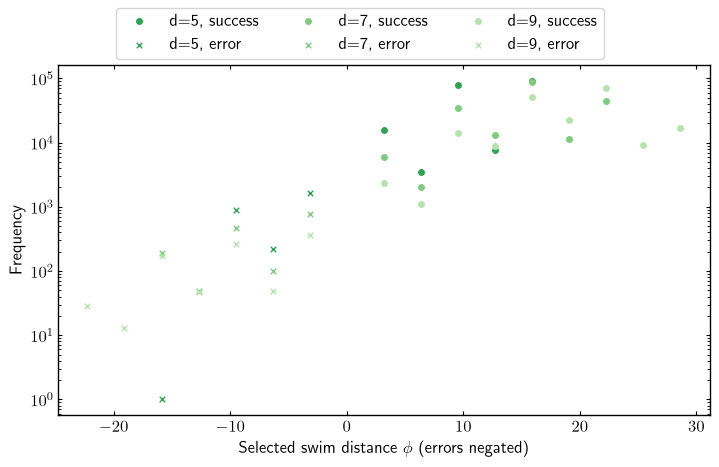

In [6]:
distribution = SwimDistanceDistributionPlotter()
figure, counts = distribution.plot(dataset, distance=[5,7,9], physical_error_rate=.04, signed_logical_errors=True)
figure

In [ ]:
figure, counts = distribution.plot(dataset, distance=7, physical_error_rate=[.02,.03,.04,.05])
figure

In [ ]:
figure, counts = distribution.plot(dataset, distance=[3,5,7,9,11,13], physical_error_rate=.04,
    signed_logical_errors=True, normalize_frequency=True)
figure

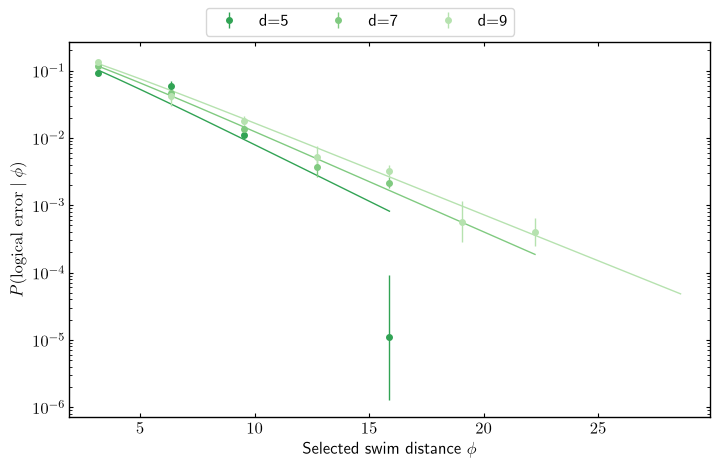

In [10]:
conditional = ConditionalLERAnalyzer()
figure, empirical_rates, fits = conditional.plot(dataset, distance=[5,7,9], physical_error_rate=.04)
figure


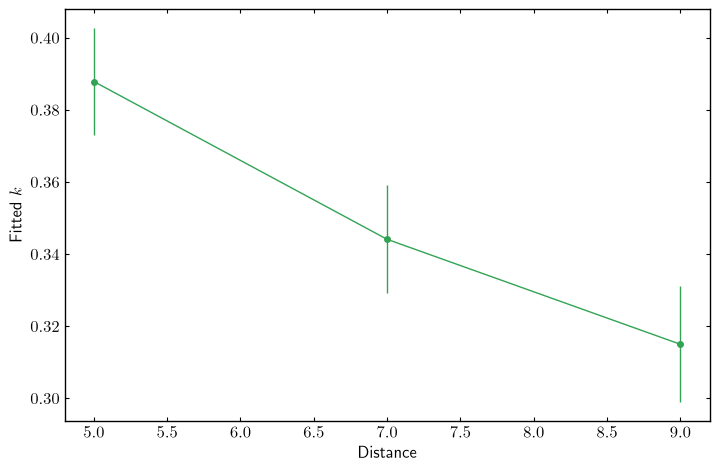

In [8]:
_, suffix = select_series([5,7,9], .04)
parameter_figures = conditional.plot_parameters(fits, output_directory=run_directory / "figures", suffix=suffix)
parameter_figures[0]

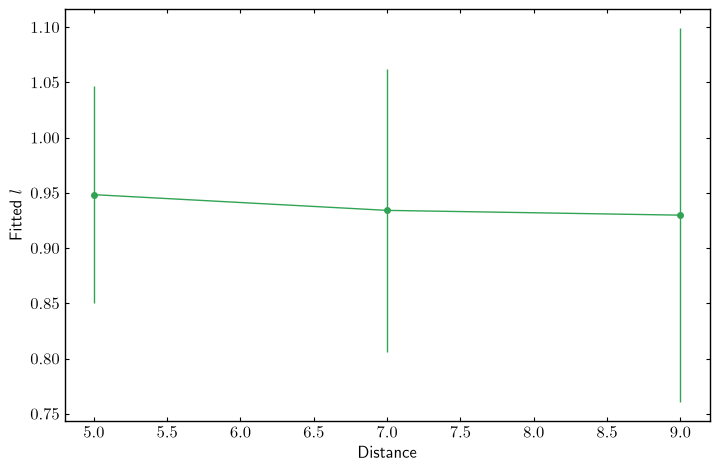

In [9]:
parameter_figures[1]

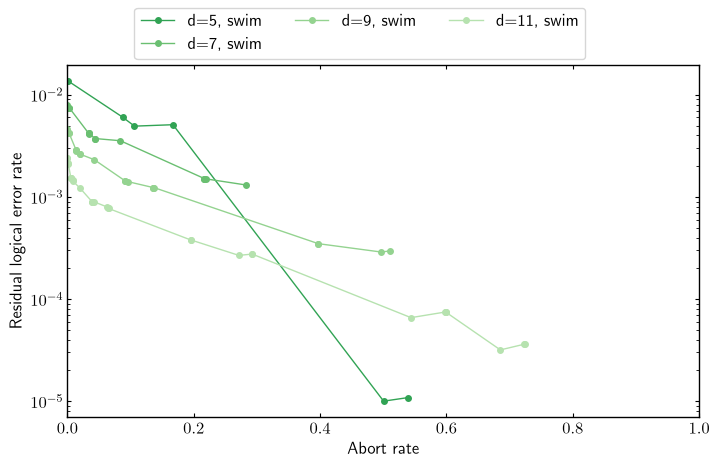

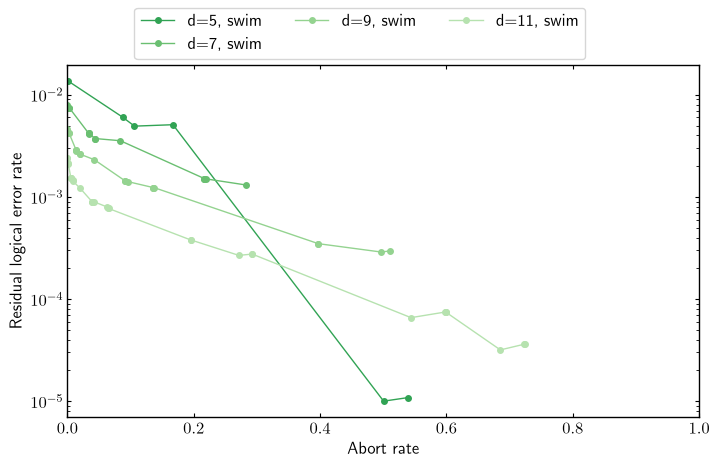

In [6]:
postselection = PostSelectionAnalyzer()
figure, retained = postselection.plot(dataset, distance=[5,7,9,11], physical_error_rate=.04)
figure

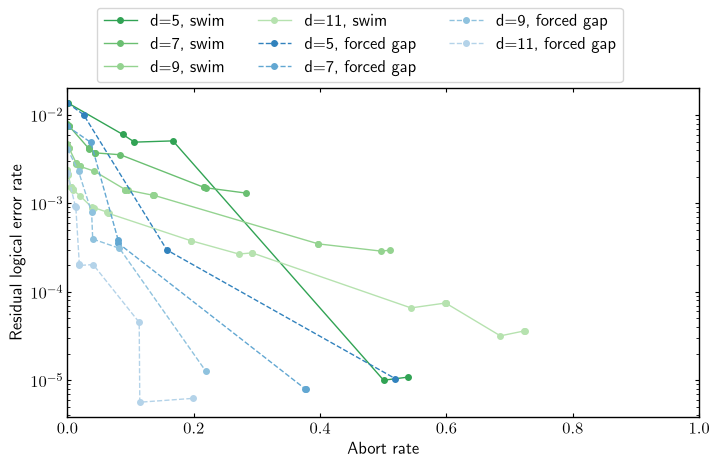

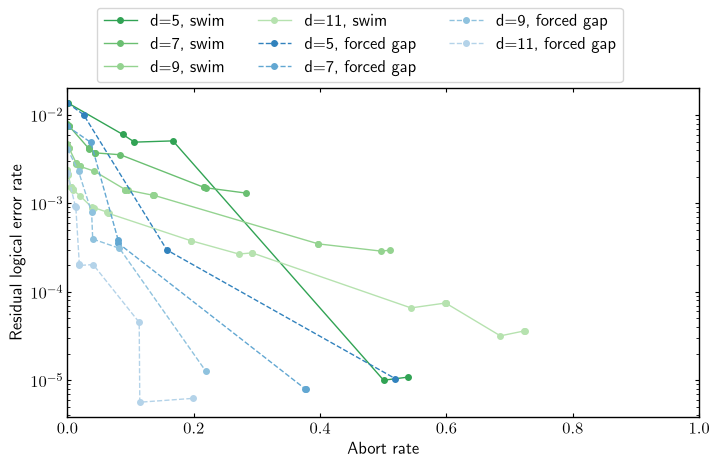

In [7]:
figure, paired_retained = postselection.plot(dataset, distance=[5,7,9,11],
    physical_error_rate=.04, include_forced_gap=True)
figure

Swim uses ordinary failure labels; forced gap aliases existing comparative logical gaps and uses comparative labels. Exact ties use stable shot identity. Counts and 99% intervals are retained in Parquet. No posterior or full-decoder theorem is claimed.